# 📊 SAP / LLM Synthetic Logs — Exploratory Visualization

This notebook explores the **`output/logs.csv`** dataset generated by `generate_synthetic_data.py`.

### Contents
1. Load & quick overview  
2. Null pattern heatmap  
3. Log-type distribution  
4. Time-series: logs over time  
5. Region & macro-region breakdown  
6. SAP application & source type  
7. Environment distribution  
8. System logs deep-dive (HTTP status, services)  
9. LLM logs deep-dive (models, tokens, cost, finish reason)  
10. Response time distributions  

In [1]:
# ── Install dependencies if needed ─────────────────────────────────────────
# Uncomment the line below only if running for the first time
# !pip install pandas matplotlib seaborn plotly nbformat --quiet

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
pd.set_option('display.max_columns', None)


# ── global style ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

ACCENT   = '#0070F3'   # SAP blue-ish
ACCENT2  = '#FF6B35'  # orange
SYS_COL  = '#4C72B0'
LLM_COL  = '#DD8452'

print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Quick Overview

In [2]:
df = pd.read_csv('/Users/santireycha/Desktop/SEC_HACK/fast_app/tests/output/ingested_logs.csv', low_memory=False)

# ── parse timestamps ────────────────────────────────────────────────────────
df['@timestamp']            = pd.to_datetime(df['@timestamp'], utc=True)
df['@event_time_requested'] = pd.to_datetime(df['@event_time_requested'], utc=True)

# ── derive handy columns ────────────────────────────────────────────────────
df['log_category'] = df['sap_function_log_type'].apply(
    lambda x: 'LLM' if str(x).startswith('LLM') else 'System'
)
df['date']  = df['@timestamp'].dt.date
df['month'] = df['@timestamp'].dt.to_period('M')
df['hour']  = df['@timestamp'].dt.hour
df['weekday'] = df['@timestamp'].dt.day_name()

# numeric coercion for LLM columns
for col in ['llm_prompt_tokens', 'llm_completion_tokens', 'llm_total_tokens',
            'llm_response_time_ms', 'llm_response_size_bytes',
            'llm_cost_usd', 'llm_temperature', 'llm_top_p',
            'sap_llm_response_size', 'sap_llm_response_time',
            'http_status_code']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range : {df["@timestamp"].min().date()} → {df["@timestamp"].max().date()}')
df.head(3)

Shape : 54,983 rows × 49 columns
Date range : 2026-03-19 → 2026-03-19


,_id,_ignored,_index,_score,@timestamp,@version,event_code_version,event_hash,@event_time_requested,headers_content_type,headers_http_host,headers_http_request_method,heathers_request_path,sap_function_application,sap_source_type,sap_function_log_type,sap_function_message,sap_app_env,sap_llm_response_size,sap_llm_response_time,region_id,region_name,region_code,macro_region,service_id,http_status_code,client_ip,llm_model_id,llm_provider,llm_prompt_id,llm_prompt_category,llm_prompt,llm_prompt_tokens,llm_completion_tokens,llm_total_tokens,llm_response_time_ms,llm_response_size_bytes,llm_status,llm_error_message,llm_cost_usd,llm_temperature,llm_top_p,llm_stream,llm_finish_reason,log_category,date,month,hour,weekday
0,c2d73565-9bb9-48d6-a380-dc3ae419cd01,NaN,sap-logs-2026.03,0.5609,2026-03-19 05:34:56+00:00,1,3.1.3,83710b0ac4dcc2e13ee16cb46d9f95b3c49e52a8b7f989...,2026-03-19 05:34:55.559000+00:00,multipart/form-data,us-tx.sap-services.internal,PUT,/api/v1/sap-fiori-launchpad/execute,sap-fiori-launchpad,BTP-Event,SECURITY,Payload marginally larger than average on sap-...,staging,NaN,NaN,NA-031,USA | Texas,US-TX,North America,auth-service,302.0,21.22.188.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,System,2026-03-19,2026-03,5,Thursday
1,b8ab55b6-9c6c-43f6-8d70-5530b927b2b0,NaN,llm-logs-2026.03,0.5748,2026-03-19 05:33:46+00:00,1,3.6.8,5764135966a09f118f106abe0778a3a003b63a6d08de17...,2026-03-19 05:33:44.027000+00:00,application/xml,llm.br-sao.sap-ai.internal,PATCH,/api/llm/sap-data-sphere/completion,sap-data-sphere,REST,LLM_ERROR,LLM ERROR: Rate limit exceeded. (model=claude-...,development,NaN,2609.0,SA-001,Brazil | São Paulo,BR-SAO,South America,NaN,NaN,NaN,claude-3-opus,Anthropic,inventory-reorder,Supply Chain,Recommend reorder quantities for low-stock ite...,1363.0,262.0,1625.0,2609.0,NaN,error,Rate limit exceeded.,0.024375,0.05,0.87,True,length,LLM,2026-03-19,2026-03,5,Thursday
2,d93dd445-bad5-46e7-8c22-75e5e575d218,NaN,sap-logs-2026.03,0.5932,2026-03-19 05:51:40+00:00,1,3.6.7,2b0532df785c38c2e0ed1a021a0d52ede780119ebc0f14...,2026-03-19 05:51:39.888000+00:00,application/json,cn-len.sap-services.internal,PUT,/api/sap-successfactors/status,sap-successfactors,BAPI,AUDIT,Admin login recorded for sap-successfactors.,development,NaN,NaN,AS-001,China | LEN CE (Primary),CN-LEN,Asia,cache-service,200.0,71.63.58.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,System,2026-03-19,2026-03,5,Thursday


In [3]:
df[df["sap_function_log_type"]=="SECURITY"]

,_id,_ignored,_index,_score,@timestamp,@version,event_code_version,event_hash,@event_time_requested,headers_content_type,headers_http_host,headers_http_request_method,heathers_request_path,sap_function_application,sap_source_type,sap_function_log_type,sap_function_message,sap_app_env,sap_llm_response_size,sap_llm_response_time,region_id,region_name,region_code,macro_region,service_id,http_status_code,client_ip,llm_model_id,llm_provider,llm_prompt_id,llm_prompt_category,llm_prompt,llm_prompt_tokens,llm_completion_tokens,llm_total_tokens,llm_response_time_ms,llm_response_size_bytes,llm_status,llm_error_message,llm_cost_usd,llm_temperature,llm_top_p,llm_stream,llm_finish_reason,log_category,date,month,hour,weekday
0,c2d73565-9bb9-48d6-a380-dc3ae419cd01,NaN,sap-logs-2026.03,0.5609,2026-03-19 05:34:56+00:00,1,3.1.3,83710b0ac4dcc2e13ee16cb46d9f95b3c49e52a8b7f989...,2026-03-19 05:34:55.559000+00:00,multipart/form-data,us-tx.sap-services.internal,PUT,/api/v1/sap-fiori-launchpad/execute,sap-fiori-launchpad,BTP-Event,SECURITY,Payload marginally larger than average on sap-...,staging,NaN,NaN,NA-031,USA | Texas,US-TX,North America,auth-service,302.0,21.22.188.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,System,2026-03-19,2026-03,5,Thursday
21,87d8ee47-a27c-4609-aff2-71e1cd9d0ab9,NaN,sap-logs-2026.03,0.6012,2026-03-19 05:41:14+00:00,1,2.3.7,7ba3c0e39c03599d4c6b1548aefdae6eed4f89bf3a75ce...,2026-03-19 05:41:13.901000+00:00,application/x-www-form-urlencoded,it-mil.sap-services.internal,GET,/api/sap-s4hana-finance/status,sap-s4hana-finance,OData,SECURITY,Non-HTTPS connection attempt noted on sap-s4ha...,sandbox,NaN,NaN,EU-019,Italy | Milan,IT-MIL,Europe,notification-service,201.0,50.49.138.115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,System,2026-03-19,2026-03,5,Thursday
32,1e00f60a-4299-4eff-87b8-2ab5b6e9180d,NaN,sap-logs-2026.03,0.6683,2026-03-19 05:59:27+00:00,1,1.7.8,c43ee22a854e625fff7c7fe43e1fcb4aa006bb812ce0d9...,2026-03-19 05:59:26.600000+00:00,application/json,ca-qc.sap-services.internal,PUT,/api/v1/sap-data-sphere/execute,sap-data-sphere,OData,SECURITY,Same user logged in from two locations on sap-...,qa,NaN,NaN,NA-003,Canada | Quebec City,CA-QC,North America,scheduler,200.0,20.114.207.221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,System,2026-03-19,2026-03,5,Thursday
38,7c7aee83-c5ad-41c8-bd43-f3f36e1203b5,NaN,sap-logs-2026.03,0.7682,2026-03-19 05:54:13+00:00,1,3.7.1,ca9fd298588eca00ac46b4f51d09e794965d41009cdb23...,2026-03-19 05:54:12.696000+00:00,application/xml,us-iad.sap-services.internal,PATCH,/api/v1/sap-analytics-cloud/execute,sap-analytics-cloud,SOAP,SECURITY,Sequential user lookups on sap-analytics-cloud...,qa,NaN,NaN,NA-024,USA | N. Virginia,US-IAD,North America,notification-service,200.0,192.168.1.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,System,2026-03-19,2026-03,5,Thursday
39,00647935-104d-4643-9473-d04b89798f91,NaN,sap-logs-2026.03,0.8551,2026-03-19 05:31:29+00:00,1,2.6.2,fb5e6a01eb3184ad6d648d1c4cb067f588a2c9b5832147...,2026-03-19 05:31:28.585000+00:00,application/xml,ae-dxb2.sap-services.internal,GET,/btp/event/sap-concur/publish,sap-concur,REST,SECURITY,Uncommon query parameter observed on sap-concu...,production,NaN,NaN,MEA-015,United Arab Emirates | Dubai (2),AE-DXB2,Middle East & Africa,analytics-engine,200.0,50.49.138.115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,System,2026-03-19,2026-03,5,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54825,18d992c0-8865-47ea-9c88-a90e09da21d7,NaN,sap-logs-2026.03,0.8224,2026-03-19 05:58:27+00:00,1,2.7.3,0589d6a63a9fbea5b4afc94c7469ab1d635ac13bb45c9b...,2026-03-19 05:58:26.889000+00:00,application/x-www-form-urlencoded,au-syd2.sap-services.internal,PUT,/sap/opu/odata/sap-data-sphere/Ent

## 2 · Null Pattern Heatmap

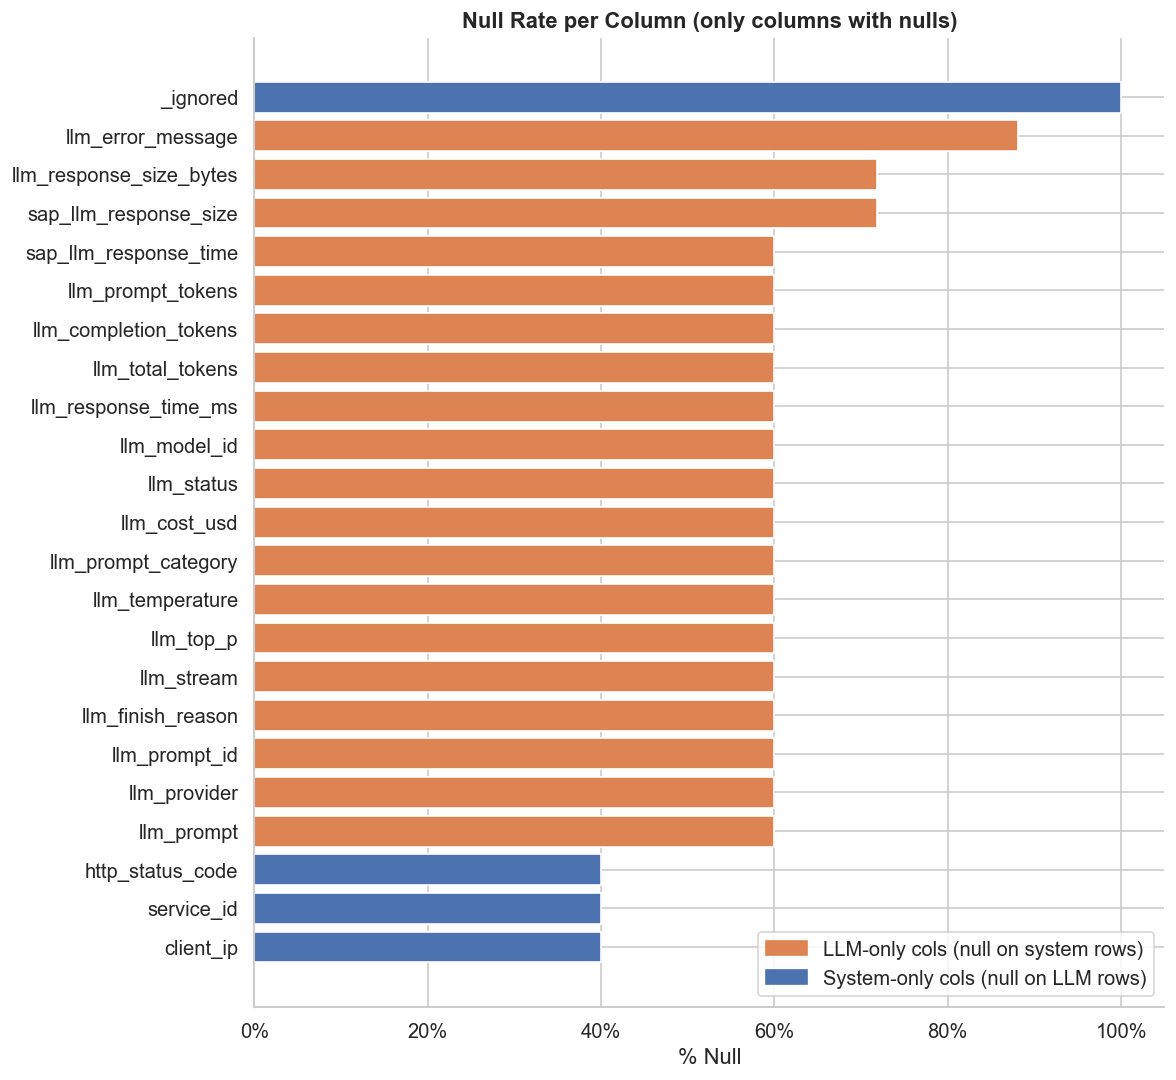

In [4]:
null_pct = df.isnull().mean().sort_values(ascending=False) * 100
null_pct = null_pct[null_pct > 0]   # only columns with at least one null

fig, ax = plt.subplots(figsize=(10, max(4, len(null_pct) * 0.4)))
bars = ax.barh(null_pct.index[::-1], null_pct.values[::-1],
               color=[LLM_COL if 'llm' in c else SYS_COL for c in null_pct.index[::-1]])
ax.set_xlabel('% Null')
ax.set_title('Null Rate per Column (only columns with nulls)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=LLM_COL, label='LLM-only cols (null on system rows)'),
    Patch(color=SYS_COL, label='System-only cols (null on LLM rows)'),
], loc='lower right')
plt.tight_layout()
plt.show()

## 3 · Log-Type Distribution

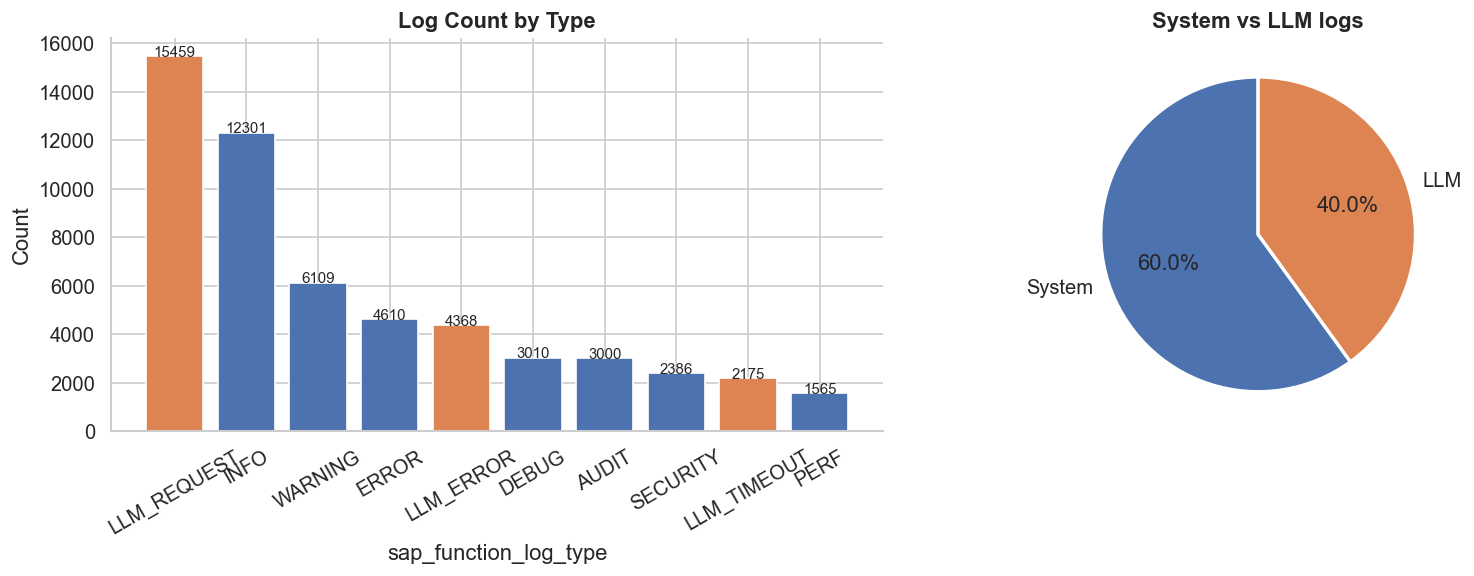

In [5]:
lt_counts = df['sap_function_log_type'].value_counts()

colors = [LLM_COL if t.startswith('LLM') else SYS_COL for t in lt_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart
axes[0].bar(lt_counts.index, lt_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Log Count by Type', fontweight='bold')
axes[0].set_xlabel('sap_function_log_type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(lt_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# pie – category level
cat = df['log_category'].value_counts()
axes[1].pie(cat, labels=cat.index, autopct='%1.1f%%',
            colors=[SYS_COL, LLM_COL], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('System vs LLM logs', fontweight='bold')

plt.tight_layout()
plt.show()

## 4 · Time Series — Logs Over Time

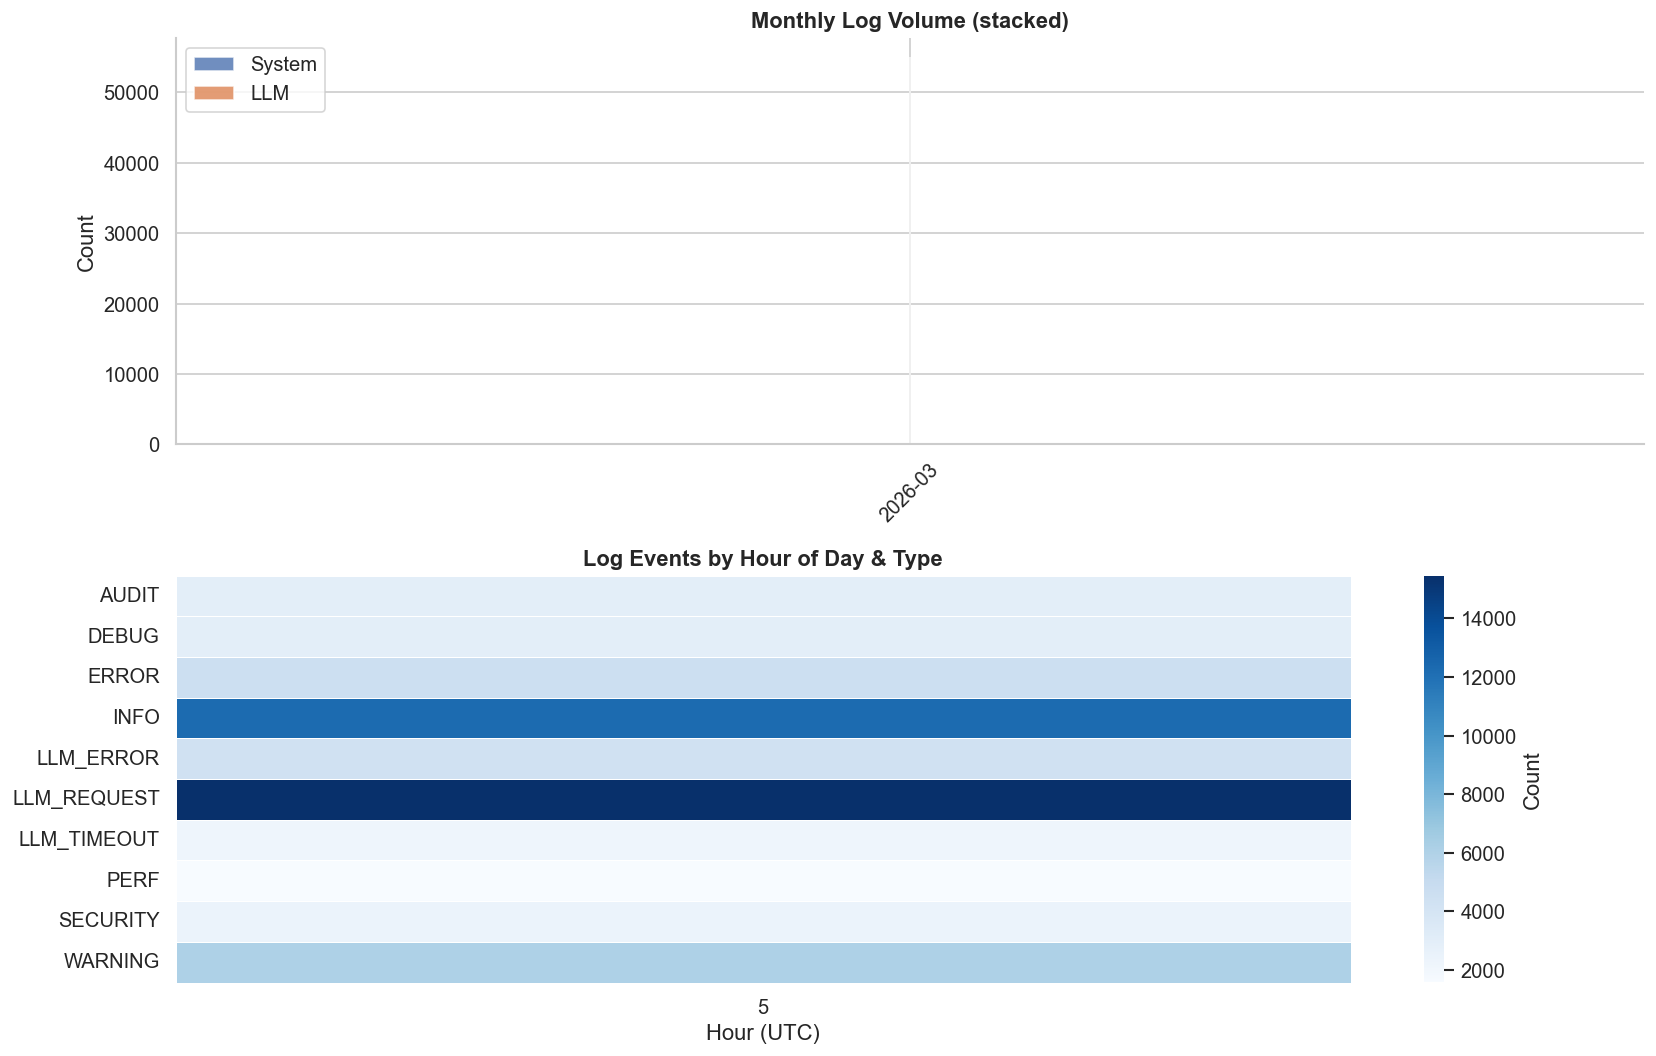

In [6]:
# ── monthly volume by category ───────────────────────────────────────────────
monthly = (df.groupby(['month', 'log_category'])
             .size()
             .unstack(fill_value=0)
             .sort_index())
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# stacked area
axes[0].stackplot(monthly.index, monthly['System'], monthly['LLM'],
                  labels=['System', 'LLM'],
                  colors=[SYS_COL, LLM_COL], alpha=0.8)
axes[0].set_title('Monthly Log Volume (stacked)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend(loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

# hourly heatmap
hourly_type = (df.groupby(['hour', 'sap_function_log_type'])
                 .size()
                 .unstack(fill_value=0))
sns.heatmap(hourly_type.T, ax=axes[1], cmap='Blues',
            linewidths=.5, linecolor='white',
            cbar_kws={'label': 'Count'})
axes[1].set_title('Log Events by Hour of Day & Type', fontweight='bold')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5 · Region & Macro-Region Breakdown

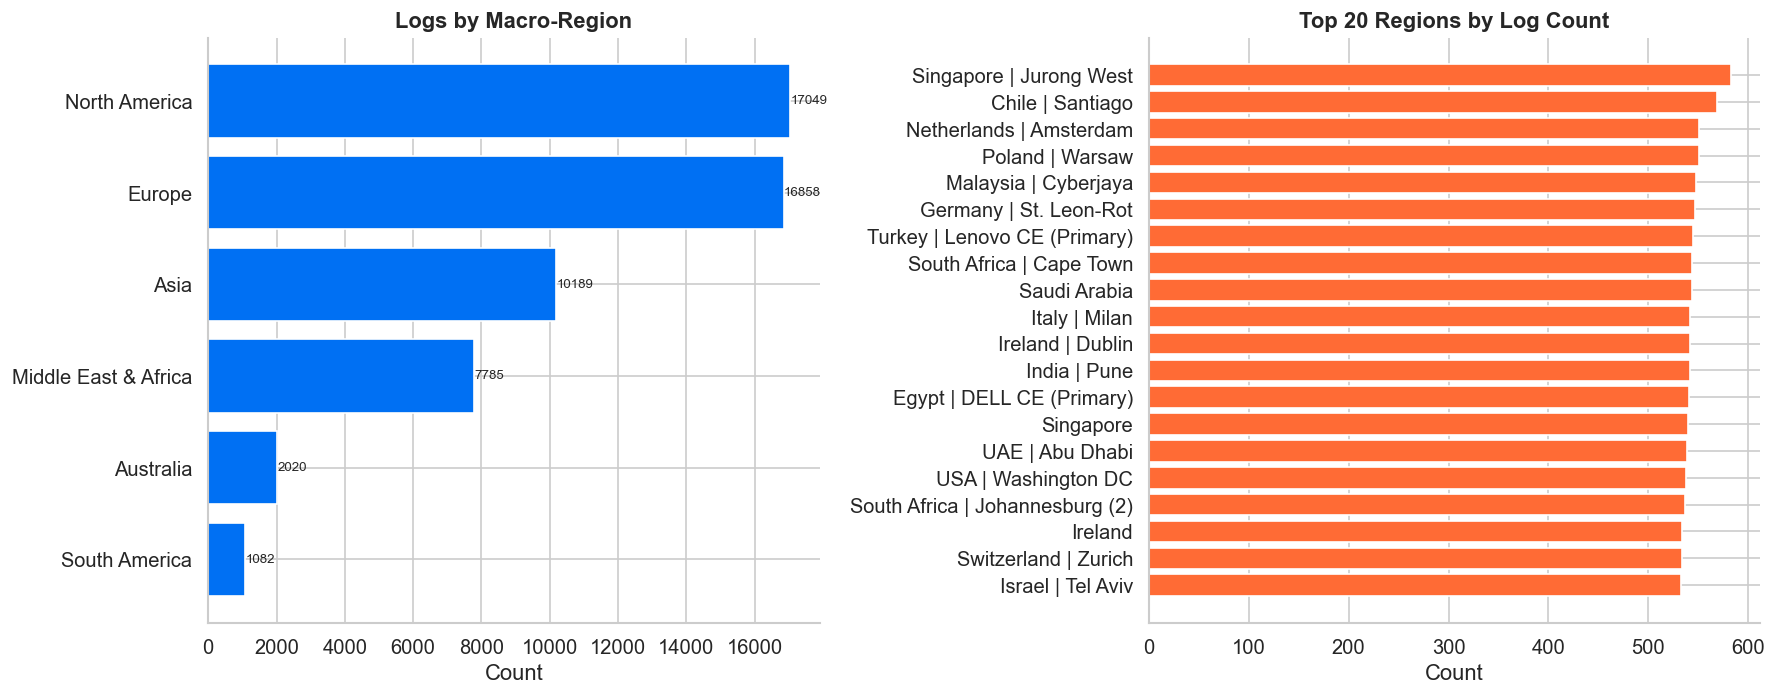

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# macro-region
macro = df['macro_region'].value_counts()
axes[0].barh(macro.index[::-1], macro.values[::-1], color=ACCENT)
axes[0].set_title('Logs by Macro-Region', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(macro.values[::-1]):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=8)

# top 20 regions
top_regions = df['region_name'].value_counts().head(20)
axes[1].barh(top_regions.index[::-1], top_regions.values[::-1], color=ACCENT2)
axes[1].set_title('Top 20 Regions by Log Count', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

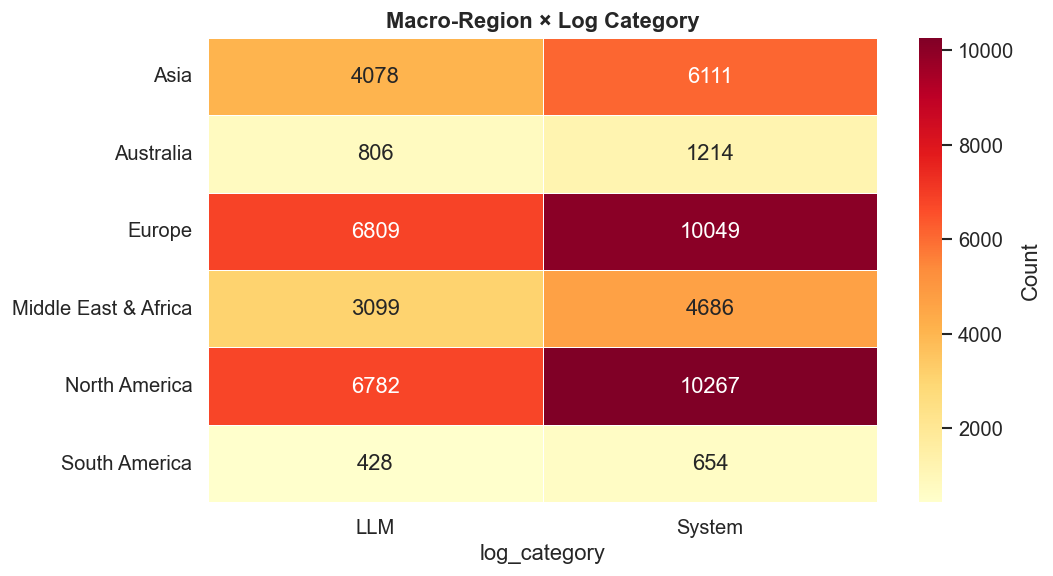

In [8]:
# Macro-region × log-type heatmap
macro_lt = (df.groupby(['macro_region', 'log_category'])
              .size()
              .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(macro_lt, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Count'})
ax.set_title('Macro-Region × Log Category', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6 · SAP Application & Source Type

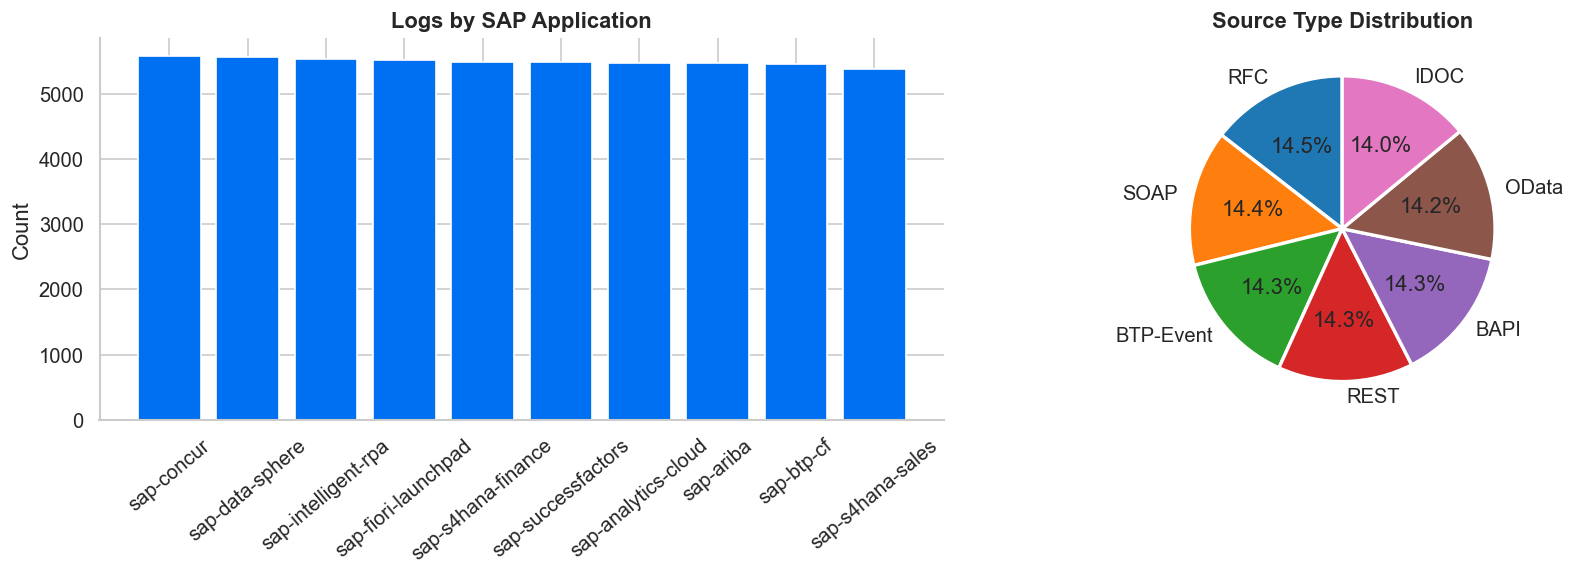

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# application
app_counts = df['sap_function_application'].value_counts()
axes[0].bar(app_counts.index, app_counts.values, color=ACCENT, edgecolor='white')
axes[0].set_title('Logs by SAP Application', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=40)

# source type
src_counts = df['sap_source_type'].value_counts()
axes[1].pie(src_counts, labels=src_counts.index, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Source Type Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

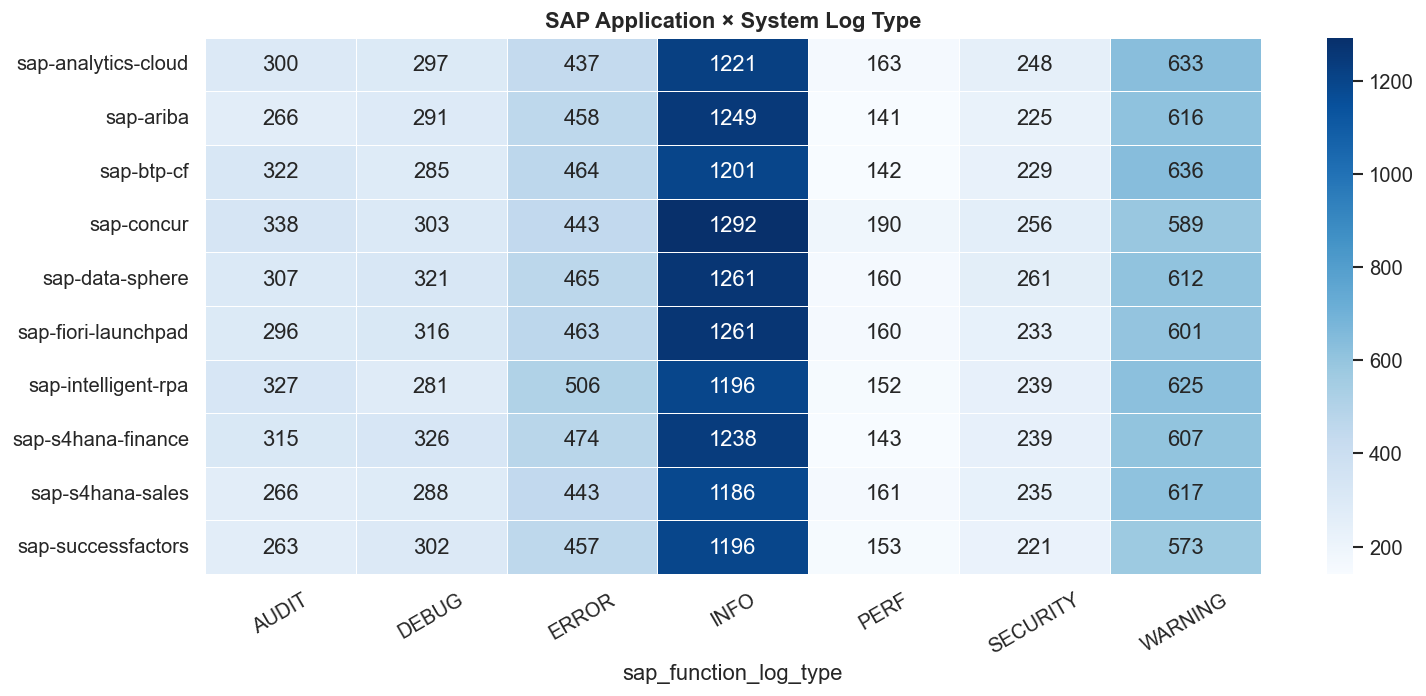

In [10]:
# App × log type heatmap (system logs only)
sys_df = df[df['log_category'] == 'System']
app_lt = (sys_df.groupby(['sap_function_application', 'sap_function_log_type'])
                .size()
                .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(app_lt, annot=True, fmt='d', cmap='Blues',
            linewidths=.5, linecolor='white', ax=ax)
ax.set_title('SAP Application × System Log Type', fontweight='bold')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 7 · Environment Distribution

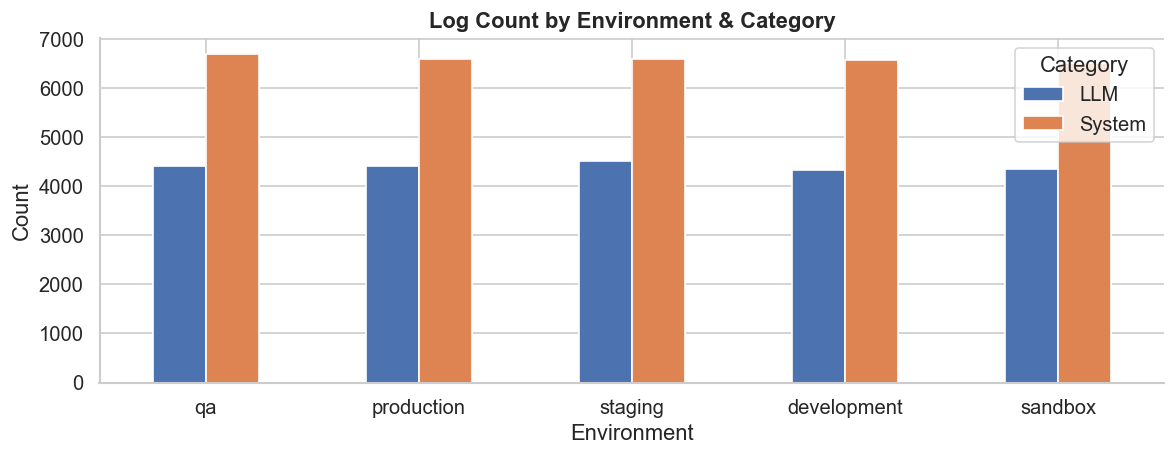

In [11]:
env_cat = (df.groupby(['sap_app_env', 'log_category'])
             .size()
             .unstack(fill_value=0)
             .sort_values('System', ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
env_cat.plot(kind='bar', ax=ax, color=[SYS_COL, LLM_COL], edgecolor='white')
ax.set_title('Log Count by Environment & Category', fontweight='bold')
ax.set_xlabel('Environment')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Category')
plt.tight_layout()
plt.show()

## 8 · System Logs Deep-Dive

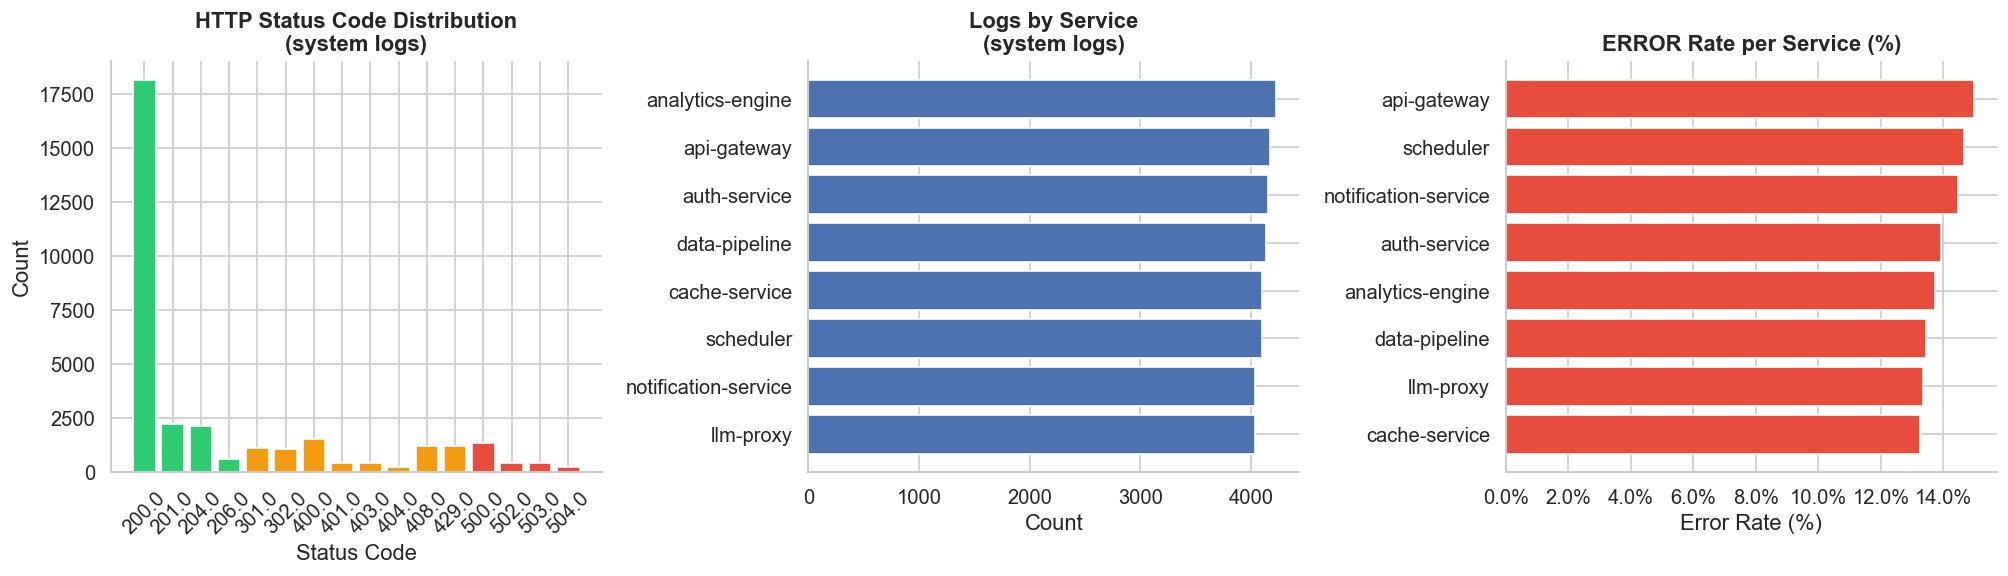

In [12]:
sys_df = df[df['log_category'] == 'System'].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# HTTP status codes
status_counts = sys_df['http_status_code'].value_counts().sort_index()
status_colors = ['#2ecc71' if s < 300 else '#f39c12' if s < 500 else '#e74c3c'
                 for s in status_counts.index]
axes[0].bar(status_counts.index.astype(str), status_counts.values,
            color=status_colors, edgecolor='white')
axes[0].set_title('HTTP Status Code Distribution\n(system logs)', fontweight='bold')
axes[0].set_xlabel('Status Code')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Service breakdown
svc_counts = sys_df['service_id'].value_counts()
axes[1].barh(svc_counts.index[::-1], svc_counts.values[::-1], color=SYS_COL)
axes[1].set_title('Logs by Service\n(system logs)', fontweight='bold')
axes[1].set_xlabel('Count')

# Error rate per service
svc_err = (sys_df[sys_df['sap_function_log_type'] == 'ERROR']
               .groupby('service_id').size())
svc_total = sys_df.groupby('service_id').size()
err_rate  = (svc_err / svc_total * 100).sort_values(ascending=False).fillna(0)
axes[2].barh(err_rate.index[::-1], err_rate.values[::-1], color='#e74c3c')
axes[2].set_title('ERROR Rate per Service (%)', fontweight='bold')
axes[2].set_xlabel('Error Rate (%)')
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

## 9 · LLM Logs Deep-Dive

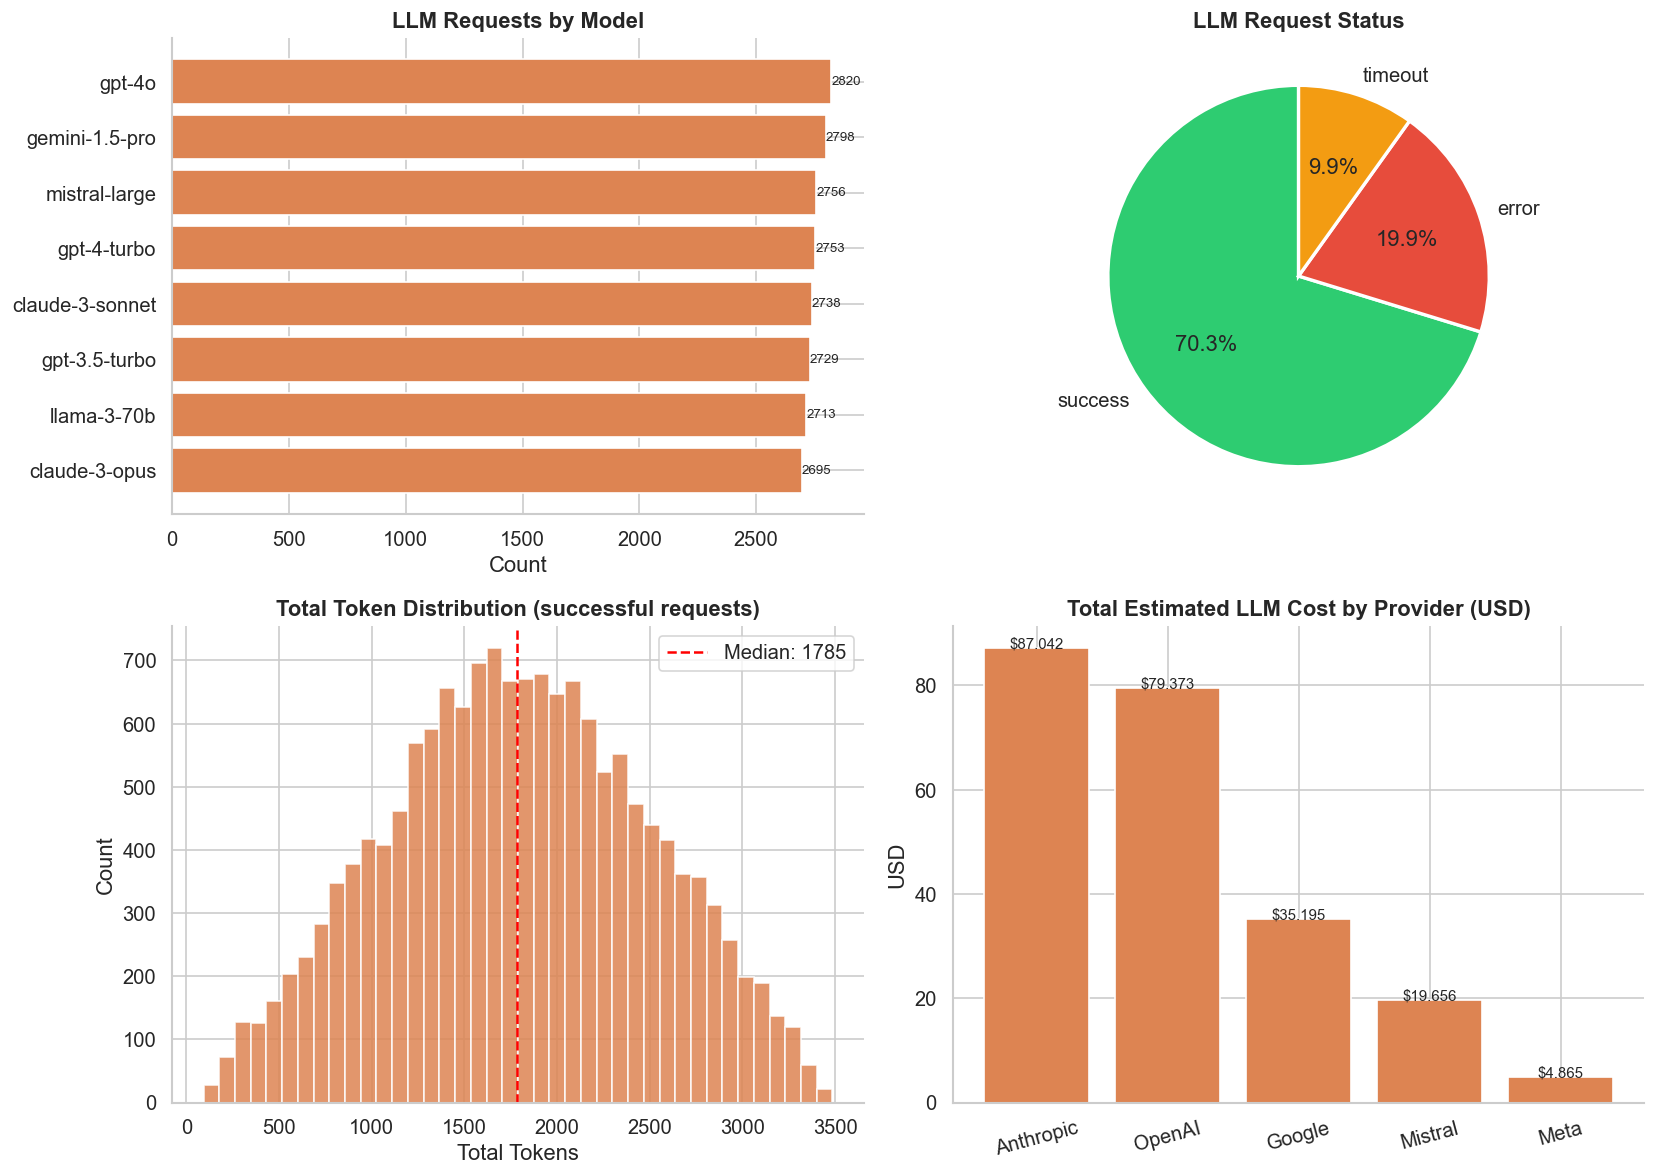

In [13]:
llm_df = df[df['log_category'] == 'LLM'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Model usage ─────────────────────────────────────────────────────────────
model_counts = llm_df['llm_model_id'].value_counts()
axes[0, 0].barh(model_counts.index[::-1], model_counts.values[::-1], color=LLM_COL)
axes[0, 0].set_title('LLM Requests by Model', fontweight='bold')
axes[0, 0].set_xlabel('Count')
for i, v in enumerate(model_counts.values[::-1]):
    axes[0, 0].text(v + 1, i, str(v), va='center', fontsize=8)

# ── LLM status breakdown ─────────────────────────────────────────────────────
status_c = llm_df['llm_status'].value_counts()
s_colors = {'success': '#2ecc71', 'error': '#e74c3c', 'timeout': '#f39c12'}
axes[0, 1].pie(status_c, labels=status_c.index, autopct='%1.1f%%',
               colors=[s_colors.get(s, '#999') for s in status_c.index],
               startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0, 1].set_title('LLM Request Status', fontweight='bold')

# ── Token distribution ───────────────────────────────────────────────────────
llm_success = llm_df[llm_df['llm_status'] == 'success']
axes[1, 0].hist(llm_success['llm_total_tokens'].dropna(), bins=40,
                color=LLM_COL, edgecolor='white', alpha=0.85)
axes[1, 0].axvline(llm_success['llm_total_tokens'].median(), color='red',
                   linestyle='--', label=f"Median: {llm_success['llm_total_tokens'].median():.0f}")
axes[1, 0].set_title('Total Token Distribution (successful requests)', fontweight='bold')
axes[1, 0].set_xlabel('Total Tokens')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# ── Cost by provider ─────────────────────────────────────────────────────────
cost_prov = (llm_df.groupby('llm_provider')['llm_cost_usd']
                   .sum()
                   .sort_values(ascending=False))
axes[1, 1].bar(cost_prov.index, cost_prov.values, color=LLM_COL, edgecolor='white')
axes[1, 1].set_title('Total Estimated LLM Cost by Provider (USD)', fontweight='bold')
axes[1, 1].set_ylabel('USD')
axes[1, 1].tick_params(axis='x', rotation=15)
for i, v in enumerate(cost_prov.values):
    axes[1, 1].text(i, v + 0.001, f'${v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

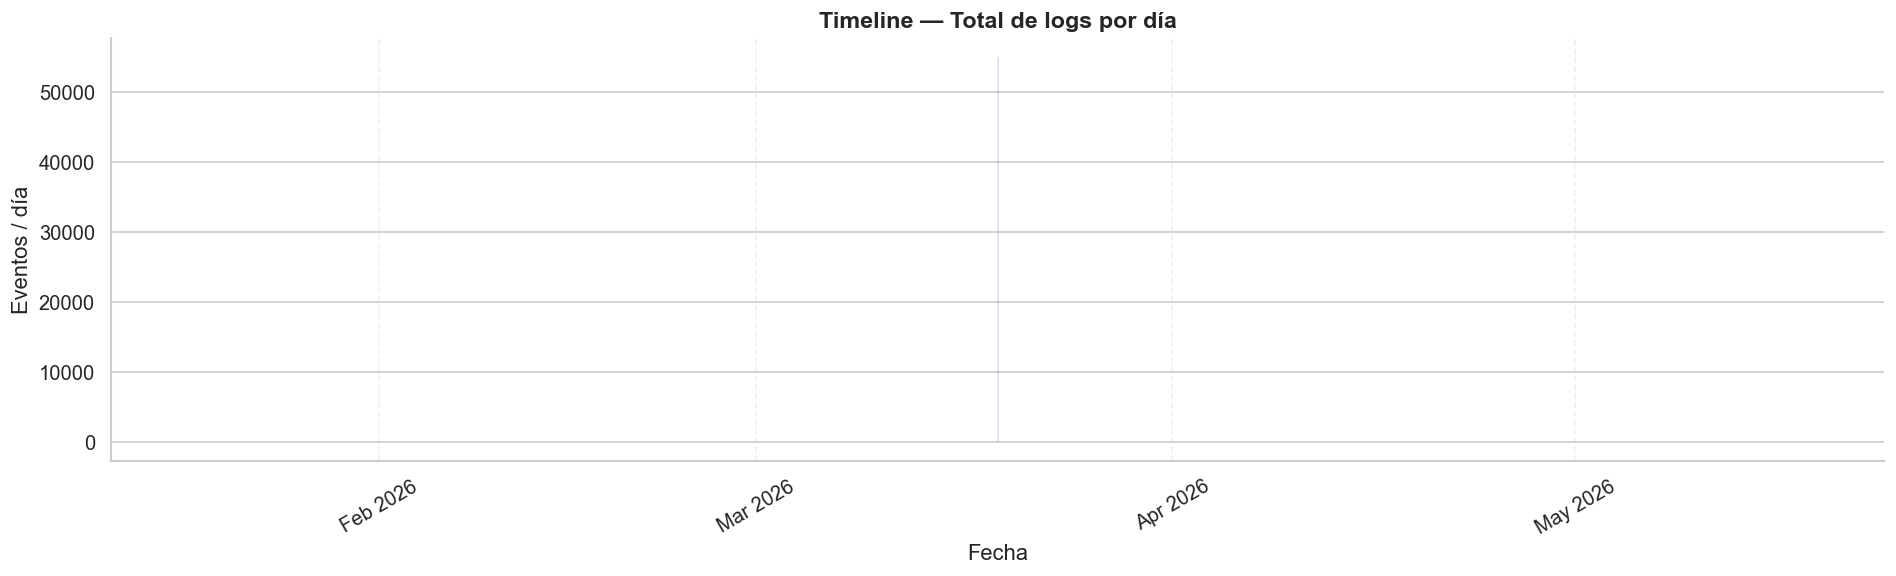

In [14]:
import matplotlib.dates as mdates

# Total de eventos por día (todos los logs, sin separar por tipo)
daily_total = (df.groupby(df['@timestamp'].dt.date)
                 .size()
                 .reset_index(name='count')
                 .rename(columns={'@timestamp': 'date'}))
daily_total['date'] = pd.to_datetime(daily_total['date'])
daily_total = daily_total.set_index('date').sort_index()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(daily_total.index, daily_total['count'], color='#4C72B0', linewidth=1.8)
ax.fill_between(daily_total.index, daily_total['count'], alpha=0.2, color='#4C72B0')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.set_title('Timeline — Total de logs por día', fontweight='bold', fontsize=14)
ax.set_ylabel('Eventos / día')
ax.set_xlabel('Fecha')
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


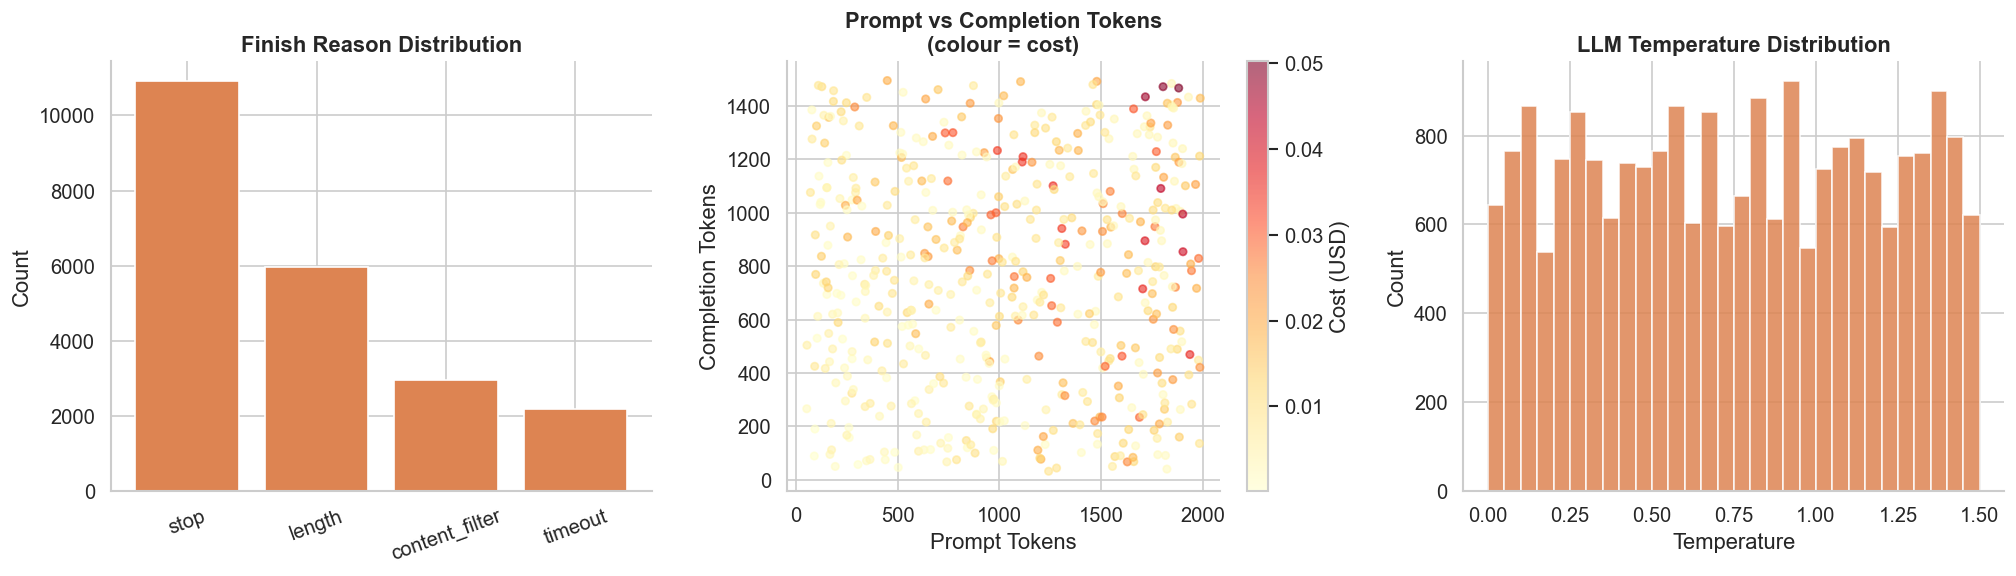

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Finish reason
fr_counts = llm_df['llm_finish_reason'].value_counts()
axes[0].bar(fr_counts.index, fr_counts.values, color=LLM_COL, edgecolor='white')
axes[0].set_title('Finish Reason Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylabel('Count')

# Prompt vs Completion tokens scatter (success only)
sample = llm_success.sample(min(500, len(llm_success)), random_state=42)
sc = axes[1].scatter(sample['llm_prompt_tokens'], sample['llm_completion_tokens'],
                     c=sample['llm_cost_usd'], cmap='YlOrRd', alpha=0.6, s=20)
plt.colorbar(sc, ax=axes[1], label='Cost (USD)')
axes[1].set_xlabel('Prompt Tokens')
axes[1].set_ylabel('Completion Tokens')
axes[1].set_title('Prompt vs Completion Tokens\n(colour = cost)', fontweight='bold')

# Temperature distribution
axes[2].hist(llm_df['llm_temperature'].dropna(), bins=30,
             color=LLM_COL, edgecolor='white', alpha=0.85)
axes[2].set_title('LLM Temperature Distribution', fontweight='bold')
axes[2].set_xlabel('Temperature')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 10 · Response Time Distributions

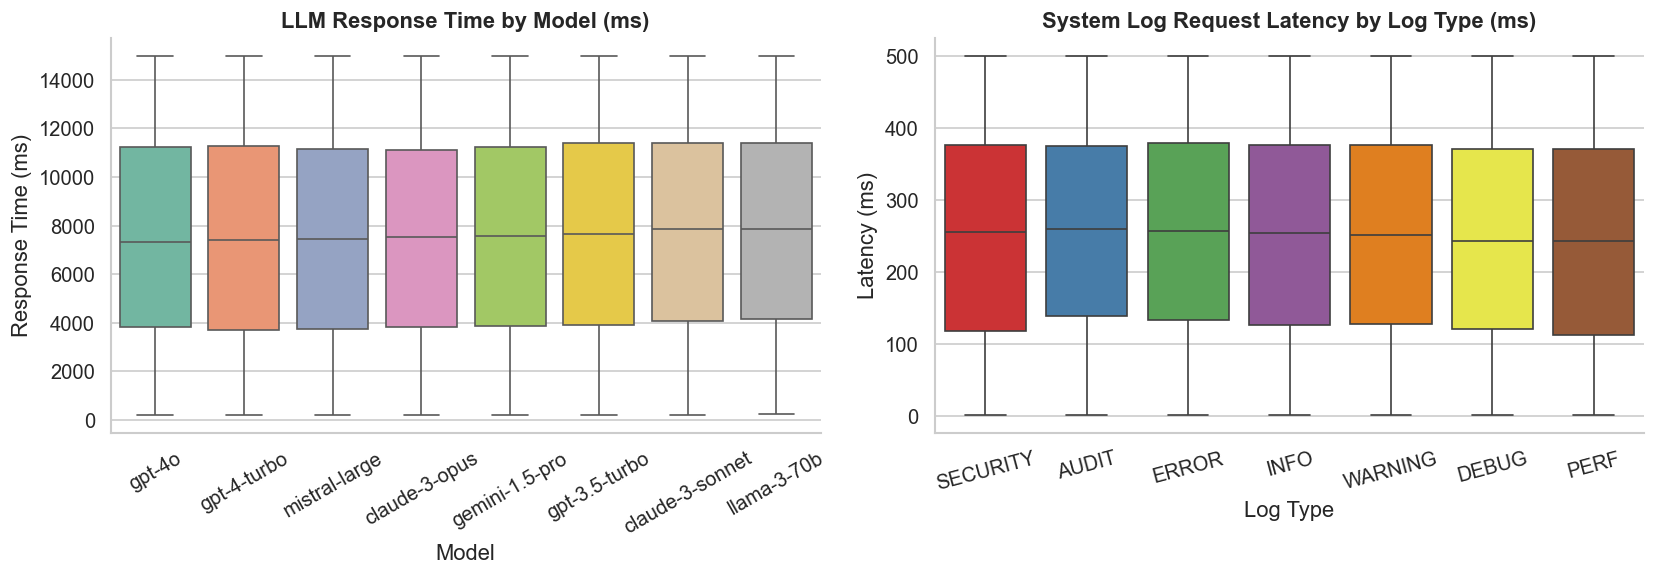

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LLM response time by model (box plot)
order = (llm_success.groupby('llm_model_id')['llm_response_time_ms']
                    .median()
                    .sort_values()
                    .index.tolist())
sns.boxplot(data=llm_success, x='llm_model_id', y='llm_response_time_ms',
            order=order, ax=axes[0],
            palette='Set2', flierprops=dict(marker='o', markersize=2, alpha=0.4))
axes[0].set_title('LLM Response Time by Model (ms)', fontweight='bold')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Response Time (ms)')
axes[0].tick_params(axis='x', rotation=30)

# System log type vs response time
sys_order = (sys_df.groupby('sap_function_log_type')['sap_llm_response_time']
                   .median()
                   .sort_values()
                   .index.tolist())
# sap_llm_response_time is null for system logs per design;
# show request latency instead (event_time_requested → timestamp delta)
sys_df['latency_ms'] = (
    (sys_df['@timestamp'] - sys_df['@event_time_requested'])
    .dt.total_seconds() * 1000
)
sns.boxplot(data=sys_df, x='sap_function_log_type', y='latency_ms',
            ax=axes[1], palette='Set1',
            flierprops=dict(marker='o', markersize=2, alpha=0.4))
axes[1].set_title('System Log Request Latency by Log Type (ms)', fontweight='bold')
axes[1].set_xlabel('Log Type')
axes[1].set_ylabel('Latency (ms)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [17]:
# ── Summary statistics table ─────────────────────────────────────────────────
print('=== Dataset Summary ===')
print(f'Total rows      : {len(df):,}')
print(f'System log rows : {len(sys_df):,}  ({len(sys_df)/len(df)*100:.1f}%)')
print(f'LLM log rows    : {len(llm_df):,}  ({len(llm_df)/len(df)*100:.1f}%)')
print(f'Unique regions  : {df["region_id"].nunique()}')
print(f'Date range      : {df["@timestamp"].min().date()} → {df["@timestamp"].max().date()}')

print('\n=== LLM Stats (successful requests only) ===')
print(llm_success[['llm_prompt_tokens','llm_completion_tokens',
                    'llm_total_tokens','llm_response_time_ms','llm_cost_usd']]
      .describe().round(2).to_string())

print('\n=== Estimated Total LLM Cost ===')
print(f'  ${llm_df["llm_cost_usd"].sum():.4f} USD')

=== Dataset Summary ===
Total rows      : 54,983
System log rows : 32,981  (60.0%)
LLM log rows    : 22,002  (40.0%)
Unique regions  : 108
Date range      : 2026-03-19 → 2026-03-19

=== LLM Stats (successful requests only) ===
       llm_prompt_tokens  llm_completion_tokens  llm_total_tokens  llm_response_time_ms  llm_cost_usd
count           15459.00               15459.00          15459.00              15459.00      15459.00
mean             1027.14                 764.57           1791.71               7583.68          0.01
std               561.68                 423.66            702.28               4272.86          0.01
min                50.00                  30.00             93.00                200.28          0.00
25%               543.00                 398.00           1290.00               3901.44          0.00
50%              1029.00                 769.00           1785.00               7580.87          0.01
75%              1513.00                1126.00           2

## 11 · Minute-level Time Series — System vs LLM

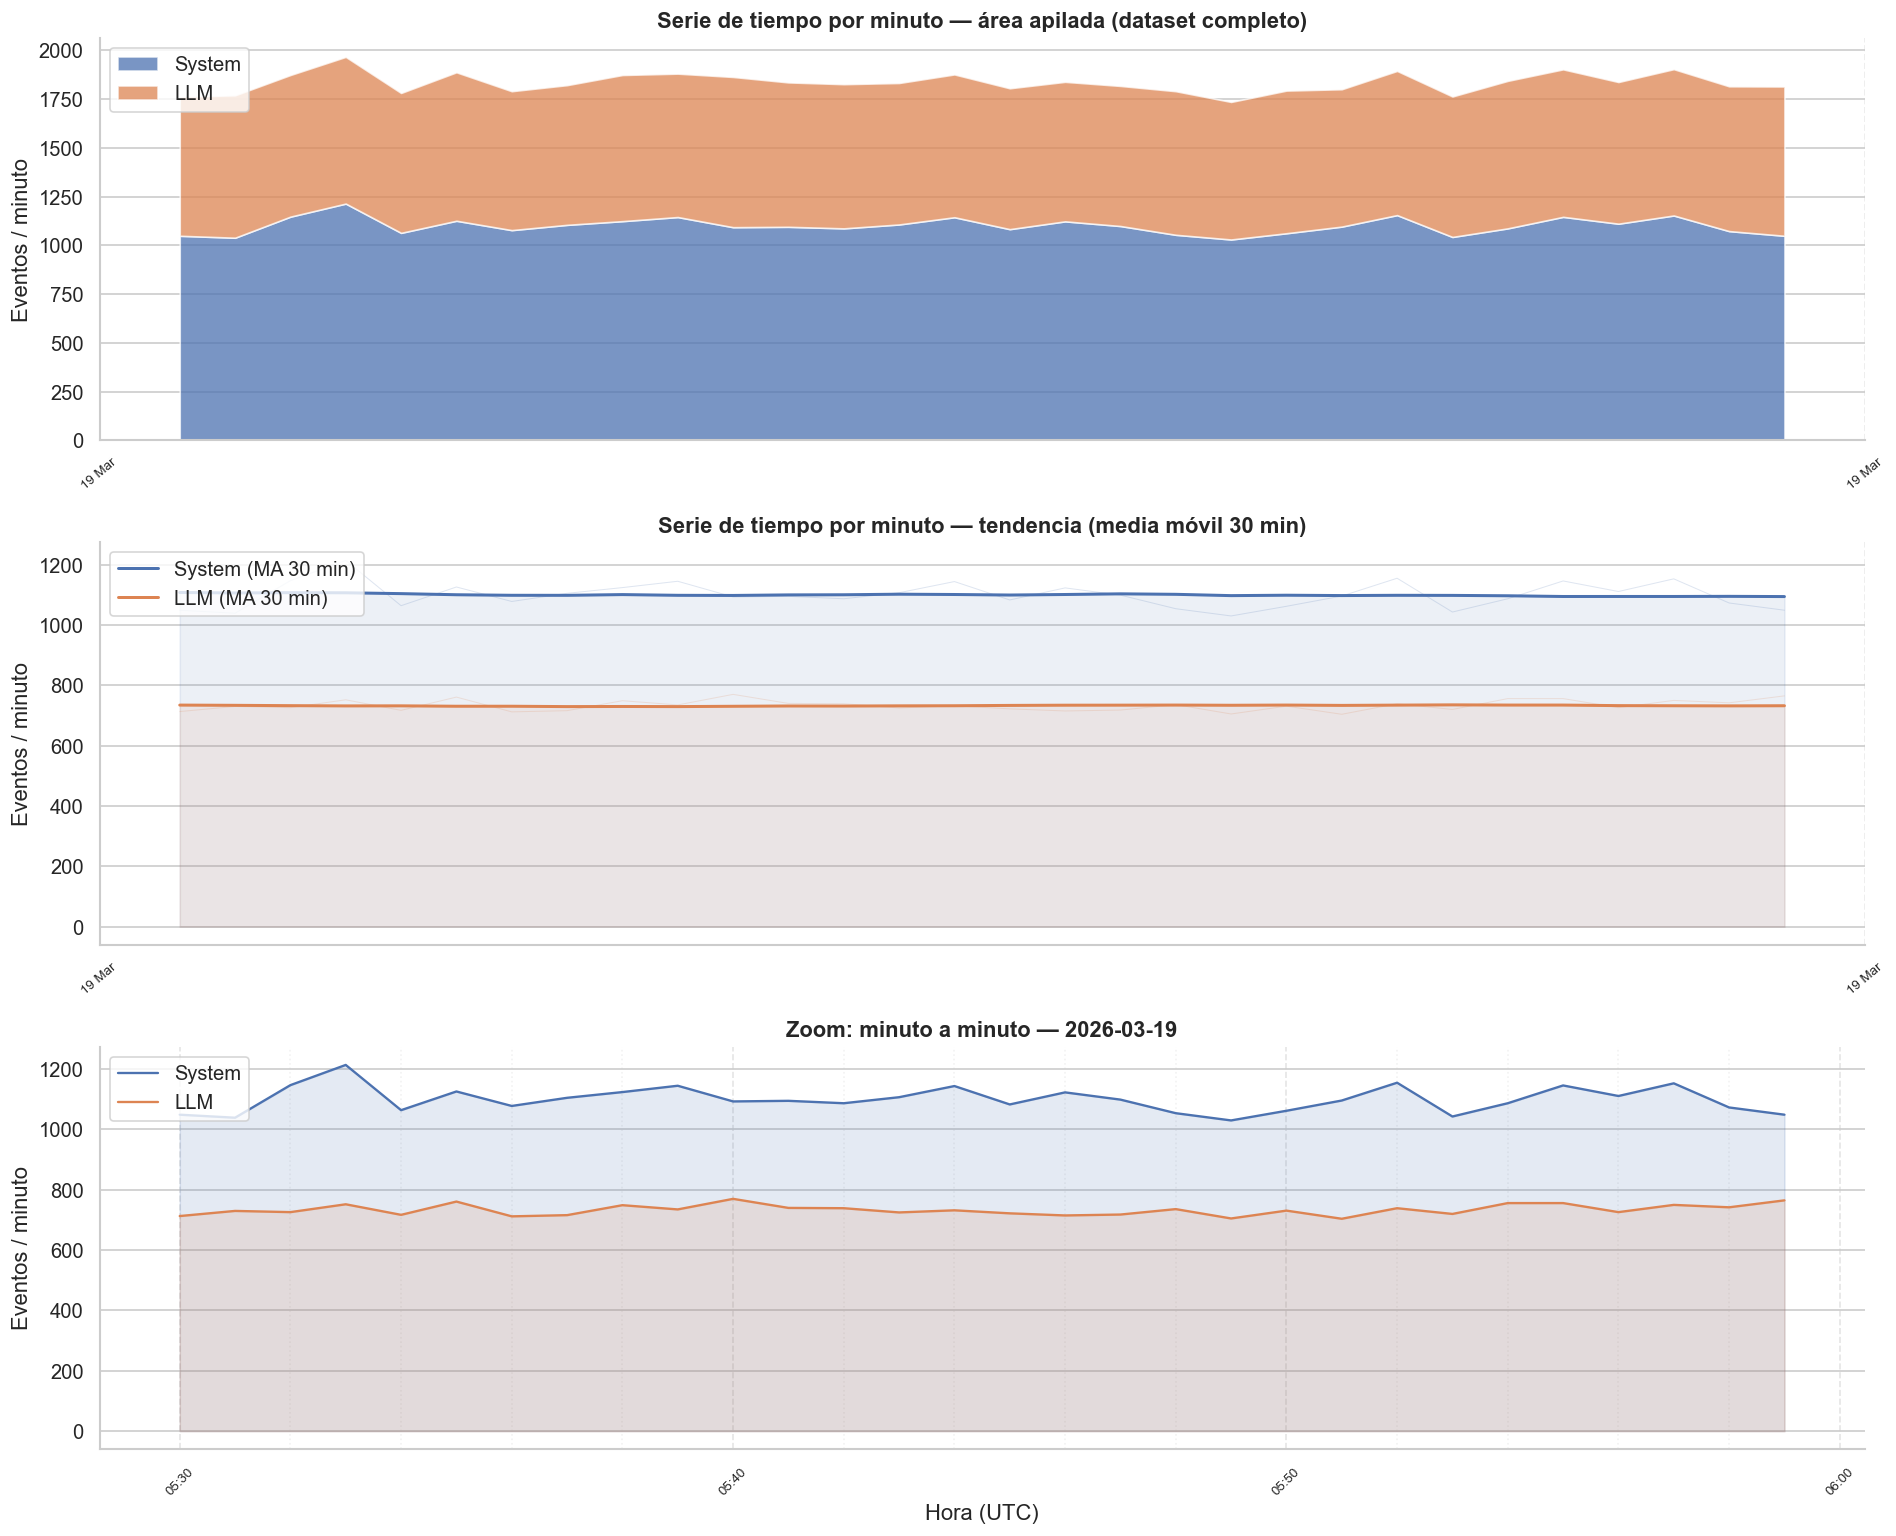

AttributeError: 'Series' object has no attribute 'maxz'

In [18]:
import matplotlib.dates as mdates

# ── 1. Resample to 1-minute bins por categoría ───────────────────────────────
df_ts = df.set_index('@timestamp').sort_index()

sys_min = df_ts[df_ts['log_category'] == 'System'].resample('1min').size().rename('System')
llm_min = df_ts[df_ts['log_category'] == 'LLM'  ].resample('1min').size().rename('LLM')

# Alinear en un solo DataFrame, rellenar minutos sin eventos con 0
min_ts = pd.concat([sys_min, llm_min], axis=1).fillna(0).astype(int)
min_ts.index = min_ts.index.tz_localize(None)   # quitar tz para simplificar ejes

# ── 2. Vista global (todo el dataset) ────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 13))

# Panel A: área apilada minuto a minuto
axes[0].stackplot(min_ts.index,
                  min_ts['System'], min_ts['LLM'],
                  labels=['System', 'LLM'],
                  colors=[SYS_COL, LLM_COL], alpha=0.75)
axes[0].set_title('Serie de tiempo por minuto — área apilada (dataset completo)',
                  fontweight='bold')
axes[0].set_ylabel('Eventos / minuto')
axes[0].legend(loc='upper left')
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[0].xaxis.set_minor_locator(mdates.DayLocator(interval=1))
axes[0].tick_params(axis='x', which='major', rotation=40, labelsize=8)
axes[0].tick_params(axis='x', which='minor', length=3)
axes[0].grid(axis='x', which='major', linestyle='--', alpha=0.4)
axes[0].grid(axis='x', which='minor', linestyle=':', alpha=0.2)

# Panel B: líneas independientes con media móvil 30 min
roll30 = min_ts.rolling(30, center=True, min_periods=1).mean()
for col, color in zip(['System', 'LLM'], [SYS_COL, LLM_COL]):
    axes[1].plot(min_ts.index, min_ts[col],
                 color=color, alpha=0.18, linewidth=0.6)
    axes[1].plot(roll30.index, roll30[col],
                 color=color, linewidth=1.8, label=f'{col} (MA 30 min)')
    axes[1].fill_between(roll30.index, roll30[col], alpha=0.10, color=color)
axes[1].set_title('Serie de tiempo por minuto — tendencia (media móvil 30 min)',
                  fontweight='bold')
axes[1].set_ylabel('Eventos / minuto')
axes[1].legend(loc='upper left')
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_minor_locator(mdates.DayLocator(interval=1))
axes[1].tick_params(axis='x', which='major', rotation=40, labelsize=8)
axes[1].tick_params(axis='x', which='minor', length=3)
axes[1].grid(axis='x', which='major', linestyle='--', alpha=0.4)
axes[1].grid(axis='x', which='minor', linestyle=':', alpha=0.2)

# Panel C: zoom en el día más reciente del dataset — ticks cada 10 min
last_day = min_ts.index.normalize().max()
day_slice = min_ts[min_ts.index.normalize() == last_day]
axes[2].plot(day_slice.index, day_slice['System'],
             color=SYS_COL, linewidth=1.4, label='System')
axes[2].plot(day_slice.index, day_slice['LLM'],
             color=LLM_COL, linewidth=1.4, label='LLM')
axes[2].fill_between(day_slice.index, day_slice['System'], alpha=0.15, color=SYS_COL)
axes[2].fill_between(day_slice.index, day_slice['LLM'],    alpha=0.15, color=LLM_COL)
axes[2].set_title(f'Zoom: minuto a minuto — {last_day.strftime("%Y-%m-%d")}',
                  fontweight='bold')
axes[2].set_ylabel('Eventos / minuto')
axes[2].set_xlabel('Hora (UTC)')
axes[2].legend(loc='upper left')
# major ticks each hour (labelled), minor ticks every 10 min (gridlines only)
# axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=1))
# axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# axes[2].xaxis.set_minor_locator(mdates.MinuteLocator(byminute=range(0, 60, 10)))


# CÓDIGO NUEVO
# Las etiquetas con texto ahora aparecerán cada 10 minutos
axes[2].xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 10)))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# (Opcional) Puedes poner marcas menores sin texto cada 2 o 5 minutos si quieres guías más finas
axes[2].xaxis.set_minor_locator(mdates.MinuteLocator(byminute=range(0, 60, 2)))

axes[2].tick_params(axis='x', which='major', rotation=45, labelsize=8)
axes[2].tick_params(axis='x', which='minor', length=4, color='gray')
axes[2].grid(axis='x', which='major', linestyle='--', alpha=0.5)
axes[2].grid(axis='x', which='minor', linestyle=':', alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Resolución: {len(min_ts):,} minutos totales '
      f'| pico System: {min_ts["System"].max()} evt/min '
      f'| pico LLM: {min_ts["LLM"].maxz()} evt/min')